<a href="https://colab.research.google.com/github/ZavalaCatalina/InteligenciaComputacional/blob/main/Feed_Forward_Network_con_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Actividad: Feed Forward Network con PyTorch

En esta actividad se creará, entrenará y evaluará una red neuronal de arquitectura feed forward (o MLP) utilizando PyTorch y el conjunto de datos MNIST.



##Importación de Librerías y Carga de Datos

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Colores
COLOR_TRAIN = "#ff7eb9" # Rosa
COLOR_VAL = "#2ecc71"   # Verde

# Transformaciones y Carga
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

full_train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Partición de datos
train_data, val_data = random_split(full_train_data, [50000, 10000])

print(f"Sets preparados: Train ({len(train_data)}), Val ({len(val_data)}), Test ({len(test_data)})")

Sets preparados: Train (50000), Val (10000), Test (10000)


##Definición del Modelo
Red neuronal con RELU

In [21]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes):
        super(MLP, self).__init__()
        layers = []
        input_size = 28 * 28

        for size in hidden_sizes:
            layers.append(nn.Linear(input_size, size))
            layers.append(nn.ReLU())
            input_size = size

        layers.append(nn.Linear(input_size, 10)) # Salida para 10 clases
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        return self.model(x)


##Loop de entrenamiento

In [22]:
def train(model, train_loader, val_loader, optimizer, criterion, epochs):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        sum_loss = 0
        for images, labels in tqdm(train_loader, desc=f"Época {epoch+1}"):
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            sum_loss += loss.item()

        # Validación
        model.eval()
        v_loss, correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                outputs = model(images)
                v_loss += criterion(outputs, labels).item()
                correct += (outputs.argmax(1) == labels).sum().item()

        avg_train_loss = sum_loss / len(train_loader)
        avg_val_loss = v_loss / len(val_loader)
        accuracy = correct / len(val_data)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(accuracy)

        print(f"Loss Train: {avg_train_loss:.4f} | Loss Val: {avg_val_loss:.4f} | Acc Val: {accuracy:.2%}")

    return history

##Experimento con 3 Configuraciones

In [26]:
configs = [
    {'layers': [128], 'opt': 'SGD', 'lr': 0.01, 'batch': 64},
    {'layers': [256, 128], 'opt': 'Adam', 'lr': 0.001, 'batch': 32},
    {'layers': [512, 256, 128], 'opt': 'Adam', 'lr': 0.0005, 'batch': 128}
]

trained_models = []

for i, c in enumerate(configs):
    print(f"\n--- Iniciando Experimento {i+1} ---")
    t_loader = DataLoader(train_data, batch_size=c['batch'], shuffle=True)
    v_loader = DataLoader(val_data, batch_size=c['batch'])

    model = MLP(c['layers'])
    optimizer = optim.SGD(model.parameters(), lr=c['lr']) if c['opt'] == 'SGD' else optim.Adam(model.parameters(), lr=c['lr'])
    criterion = nn.CrossEntropyLoss()

    results = train(model, t_loader, v_loader, optimizer, criterion, epochs=10)
    trained_models.append((model, results))

# Gráfica del mejor modelo



--- Iniciando Experimento 1 ---


Época 1: 100%|██████████| 782/782 [00:10<00:00, 72.11it/s]


Loss Train: 0.6216 | Loss Val: 0.3476 | Acc Val: 89.97%


Época 2: 100%|██████████| 782/782 [00:10<00:00, 74.08it/s]


Loss Train: 0.3159 | Loss Val: 0.2871 | Acc Val: 91.53%


...

Loss Train: 0.0212 | Loss Val: 0.0800 | Acc Val: 98.02%


Época 9: 100%|██████████| 391/391 [00:12<00:00, 30.20it/s]


Loss Train: 0.0143 | Loss Val: 0.1217 | Acc Val: 97.19%


Época 10: 100%|██████████| 391/391 [00:12<00:00, 30.18it/s]


Loss Train: 0.0184 | Loss Val: 0.0911 | Acc Val: 97.96%


##Mejor modelo
Se identifica el mejor modelo tomando como base el accuracy de validación.

El mejor modelo fue el Experimento 3 con un Accuracy de Validación de: 97.96%

RESULTADOS FINALES EN EL CONJUNTO DE PRUEBA (TEST):
Average loss: 0.0008
Accuracy: 9787/10000 (97.87%)


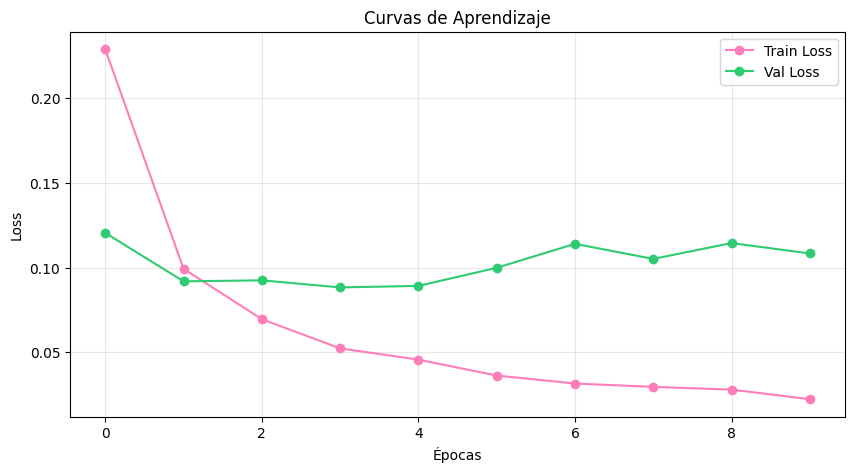

In [27]:
#  Identificar el mejor modelo basado en el accuracy de validación
best_experiment_idx = 0
best_val_acc = 0.0

# Iterar por los modelos entrenados
for i, (model, history) in enumerate(trained_models):
    #tomar el accuracy del historial
    current_val_acc = history['val_acc'][-1]
    if current_val_acc > best_val_acc:
        best_val_acc = current_val_acc
        best_experiment_idx = i

# Regresa el mejor modelo
best_model, _ = trained_models[best_experiment_idx]
print(f"El mejor modelo fue el Experimento {best_experiment_idx + 1} con un Accuracy de Validación de: {best_val_acc:.2%}")

# Define the test_loader
test_loader = DataLoader(test_data, batch_size=100)

# Evaluación final con el conjunto de TEST
best_model.eval()
test_loss = 0
correct = 0
criterion = nn.CrossEntropyLoss()

with torch.no_grad():
    for data, target in test_loader:
        # Si tus imágenes vienen en (Batch, 1, 28, 28) hay que aplanarlas
        data = data.view(-1, 28*28)
        output = best_model(data)
        test_loss += criterion(output, target).item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()

test_loss /= len(test_loader.dataset)
test_accuracy = 100. * correct / len(test_loader.dataset)

print(f'\nRESULTADOS FINALES EN EL CONJUNTO DE PRUEBA (TEST):')
print(f'Average loss: {test_loss:.4f}')
print(f'Accuracy: {correct}/{len(test_loader.dataset)} ({test_accuracy:.2f}%)')

# Gráfica del mejor modelo
best_results = trained_models[1][1]
plt.figure(figsize=(10, 5))
plt.plot(best_results['train_loss'], color=COLOR_TRAIN, label='Train Loss', marker='o')
plt.plot(best_results['val_loss'], color=COLOR_VAL, label='Val Loss', marker='o')
plt.title("Curvas de Aprendizaje")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


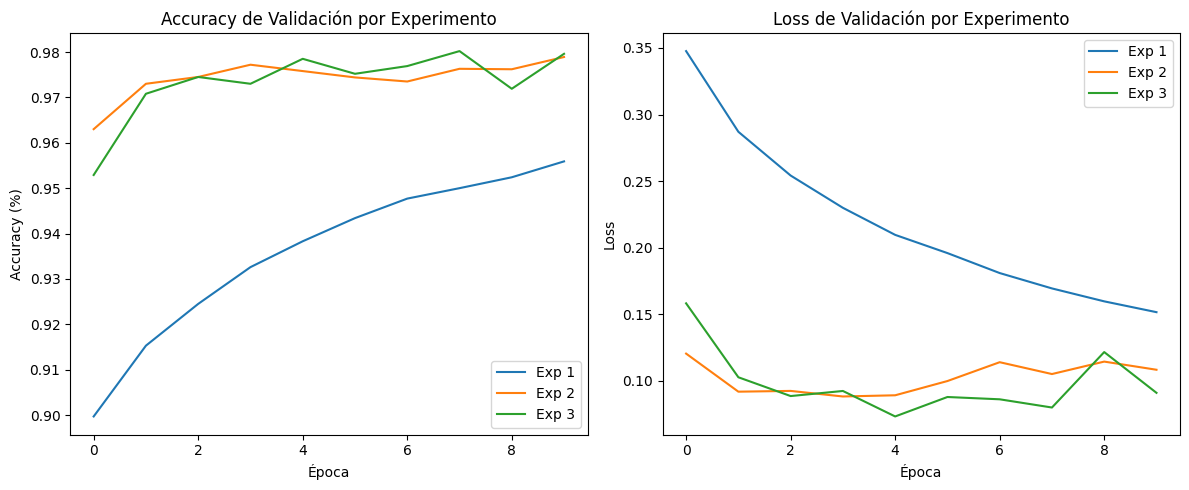

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Gráfica de Accuracy de Validación
plt.subplot(1, 2, 1)

for i, (model, history) in enumerate(trained_models):
    plt.plot(history['val_acc'], label=f'Exp {i+1}')
plt.title('Accuracy de Validación por Experimento')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.legend()

# Gráfica de Loss de Validación
plt.subplot(1, 2, 2)

for i, (model, history) in enumerate(trained_models):
    plt.plot(history['val_loss'], label=f'Exp {i+1}')
plt.title('Loss de Validación por Experimento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

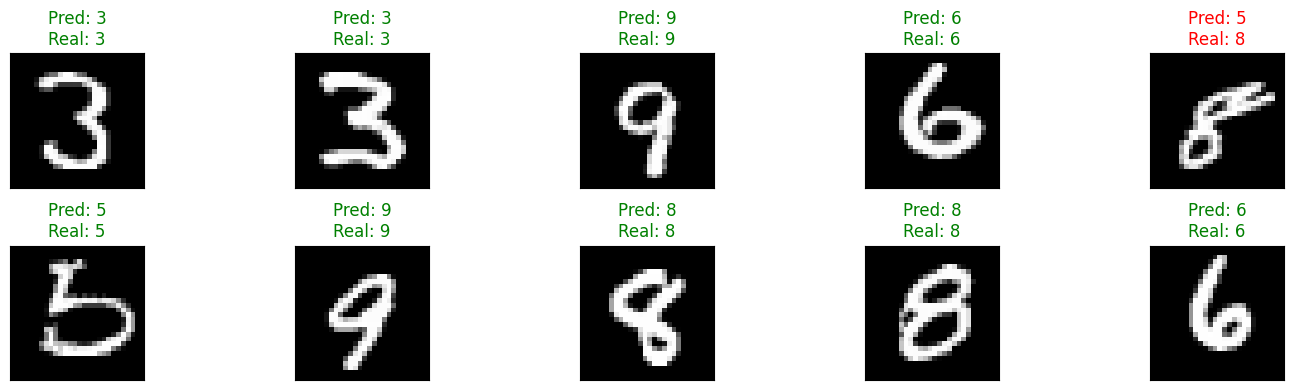

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def visualizar_predicciones(model, dataset, num_images=10):
    model.eval()
    fig = plt.figure(figsize=(15, 4))

    # Seleccion de índices aleatorios del conjunto de prueba
    indices = np.random.choice(len(dataset), num_images, replace=False)

    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, label = dataset[idx]

            # Prepararacion de la imagen, aplanar
            image_input = image.view(-1, 28*28)
            output = model(image_input)
            prediction = output.argmax(dim=1, keepdim=True).item()

            # Mostrar la imagen
            ax = fig.add_subplot(2, num_images//2, i+1, xticks=[], yticks=[])
            plt.imshow(image.squeeze(), cmap='gray')

            # Color verde si acertó, rojo si falló
            color = "green" if prediction == label else "red"
            ax.set_title(f"Pred: {prediction}\nReal: {label}", color=color)

# Llamar a la función con el mejor modelo y el dataset de prueba
visualizar_predicciones(best_model, test_data)
plt.tight_layout()
plt.show()

##Reflexiones

Esta actividad me parecio interesante, considero importante comprender el funcionamiento de una red neuronal al implementar manualmente cada etapa del aprendizaje con PyTorch. La transición de la teoría al entrenamiento real demuestra que la selección de hiperparámetros, como el optimizador y la tasa de aprendizaje, tiene gran impacto en la convergencia y estabilidad del modelo.

Respecto a los resultados, se observa que incluso con un alto índice de precisión, pueden haber ambigüedades.

Nota: es importante mencionar que se utilizo apoyo de IA  para completar algunas secciones del código, como en la lógica de las visualizaciones, el cálculo de métricas de desempeño.

##Puntos extras

 Reporte de clasificación que incluya matriz de confusión, accuracy (global), recall (por clase), precision (por clase) y f1-score (por clase).

Clase  | Prec.   | Recall  | F1     
-----------------------------------
0      | 0.9827 | 0.9878 | 0.9852
1      | 0.9920 | 0.9885 | 0.9903
2      | 0.9833 | 0.9709 | 0.9771
3      | 0.9588 | 0.9911 | 0.9747
4      | 0.9728 | 0.9837 | 0.9782
5      | 0.9841 | 0.9686 | 0.9763
6      | 0.9926 | 0.9760 | 0.9842
7      | 0.9630 | 0.9883 | 0.9755
8      | 0.9841 | 0.9517 | 0.9676
9      | 0.9713 | 0.9732 | 0.9723


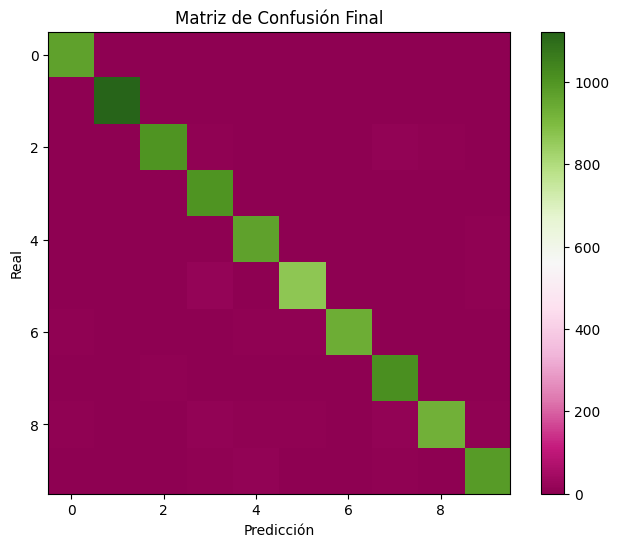

In [31]:
best_model = trained_models[1][0]
best_model.eval()

confusion_matrix = np.zeros((10, 10), dtype=int)

with torch.no_grad():
    for imgs, labels in DataLoader(test_data, batch_size=100):
        preds = best_model(imgs).argmax(1)
        for l, p in zip(labels.numpy(), preds.numpy()):
            confusion_matrix[l, p] += 1

print(f"{'Clase':<6} | {'Prec.':<7} | {'Recall':<7} | {'F1':<7}")
print("-" * 35)

for i in range(10):
    tp = confusion_matrix[i, i]
    prec = tp / confusion_matrix[:, i].sum() if confusion_matrix[:, i].sum() > 0 else 0
    rec = tp / confusion_matrix[i, :].sum() if confusion_matrix[i, :].sum() > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    print(f"{i:<6} | {prec:.4f} | {rec:.4f} | {f1:.4f}")

# Visualización de Matriz de Confusión
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, cmap='PiYG')
plt.title("Matriz de Confusión Final")
plt.colorbar()
plt.ylabel("Real")
plt.xlabel("Predicción")
plt.show()

Este reporte de metricas por clase ayuda a ver si el modelo confunde números similares (como el 4 y el 9 o el 7 y 1) a pesar de tener un accuracy global alto.